# NIFTY 50 Forecasting — Step 3: Facebook Prophet
**Input:** `nifty50_with_indicators.csv` (from Step 1)  
**Goal:** Forecast NIFTY 50 using Prophet → add Indian market holidays → compare vs ARIMA baseline (0.66% MAPE)

**Why Prophet is different from ARIMA:**
- ARIMA looks at autocorrelation (yesterday predicts today)
- Prophet decomposes into **trend + seasonality + holidays** separately
- Prophet handles missing dates, outliers, and regime changes automatically
- Great at capturing yearly patterns (budget day, Diwali rally, etc.)

---

## 0. Install dependencies

In [2]:
import sys
!{sys.executable} -m pip install prophet --quiet
print('Done!')

Done!



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('All imports successful!')

Importing plotly failed. Interactive plots will not work.


All imports successful!


## 2. Load & prepare data
Prophet requires a specific format: columns must be named **`ds`** (date) and **`y`** (value).

In [4]:
df = pd.read_csv('nifty50_with_indicators.csv', index_col=0, parse_dates=True)

# Prophet requires ds and y columns — no other format accepted
prophet_df = df[['Close']].reset_index()
prophet_df.columns = ['ds', 'y']
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

print(f'Shape: {prophet_df.shape}')
print(f'Date range: {prophet_df.ds.min().date()} → {prophet_df.ds.max().date()}')
prophet_df.tail(5)

Shape: (1278, 2)
Date range: 2019-10-31 → 2024-12-30


,ds,y
1273,2024-12-23,23753.449219
1274,2024-12-24,23727.650391
1275,2024-12-26,23750.199219
1276,2024-12-27,23813.400391
1277,2024-12-30,23644.900391


## 3. Train / Test split
Same 60-day test set as ARIMA — fair comparison.

In [5]:
TEST_SIZE = 60

train_df = prophet_df.iloc[:-TEST_SIZE].copy()
test_df  = prophet_df.iloc[-TEST_SIZE:].copy()

print(f'Train: {len(train_df)} rows  ({train_df.ds.iloc[0].date()} → {train_df.ds.iloc[-1].date()})')
print(f'Test : {len(test_df)}  rows  ({test_df.ds.iloc[0].date()}  → {test_df.ds.iloc[-1].date()})')

Train: 1218 rows  (2019-10-31 → 2024-10-01)
Test : 60  rows  (2024-10-03  → 2024-12-30)


## 4. Define Indian Market Holidays
Prophet can factor in known holidays — this is a huge advantage over ARIMA.  
NIFTY often rallies/drops around budget day, Diwali, RBI policy announcements.

In [6]:
# NSE holidays 2019-2024
# These are actual NSE trading holidays
indian_holidays = pd.DataFrame({
    'holiday': [
        # 2019
        'Republic Day',      'Mahashivratri',    'Holi',
        'Ram Navami',        'Mahavir Jayanti',  'Good Friday',
        'Buddha Purnima',    'Id-ul-Fitr',       'Eid ul Adha',
        'Independence Day',  'Ganesh Chaturthi', 'Dussehra',
        'Diwali Laxmi Puja','Diwali Balipratipada','Gurunanak Jayanti',
        'Christmas',
        # 2020
        'Mahashivratri 20',  'Holi 20',          'Good Friday 20',
        'Ram Navami 20',     'Buddha Purnima 20','Id-ul-Fitr 20',
        'Eid ul Adha 20',    'Independence Day 20','Ganesh Chaturthi 20',
        'Dussehra 20',       'Diwali 20',         'Gurunanak 20',
        'Christmas 20',
        # 2021
        'Republic Day 21',   'Mahashivratri 21', 'Holi 21',
        'Good Friday 21',    'Id-ul-Fitr 21',    'Buddha Purnima 21',
        'Eid ul Adha 21',    'Independence Day 21','Ganesh Chaturthi 21',
        'Dussehra 21',       'Diwali 21',         'Gurunanak 21',
        'Christmas 21',
        # 2022
        'Republic Day 22',   'Mahashivratri 22', 'Holi 22',
        'Good Friday 22',    'Ram Navami 22',    'Id-ul-Fitr 22',
        'Buddha Purnima 22', 'Eid ul Adha 22',   'Independence Day 22',
        'Dussehra 22',       'Diwali 22',         'Gurunanak 22',
        'Christmas 22',
        # 2023
        'Republic Day 23',   'Mahashivratri 23', 'Holi 23',
        'Ram Navami 23',     'Mahavir Jayanti 23','Good Friday 23',
        'Id-ul-Fitr 23',     'Buddha Purnima 23','Eid ul Adha 23',
        'Independence Day 23','Dussehra 23',     'Diwali 23',
        'Gurunanak 23',      'Christmas 23',
        # 2024
        'Republic Day 24',   'Mahashivratri 24', 'Holi 24',
        'Good Friday 24',    'Id-ul-Fitr 24',    'Buddha Purnima 24',
        'Eid ul Adha 24',    'Independence Day 24','Dussehra 24',
        'Diwali 24',         'Gurunanak 24',      'Christmas 24',
        # Budget days (high impact)
        'Union Budget 2019', 'Union Budget 2020', 'Union Budget 2021',
        'Union Budget 2022', 'Union Budget 2023', 'Union Budget 2024',
    ],
    'ds': pd.to_datetime([
        # 2019
        '2019-01-26','2019-03-04','2019-03-21',
        '2019-04-14','2019-04-17','2019-04-19',
        '2019-05-18','2019-06-05','2019-08-12',
        '2019-08-15','2019-09-02','2019-10-08',
        '2019-10-27','2019-10-28','2019-11-12',
        '2019-12-25',
        # 2020
        '2020-02-21','2020-03-10','2020-04-10',
        '2020-04-02','2020-05-07','2020-05-25',
        '2020-07-31','2020-08-15','2020-08-22',
        '2020-10-25','2020-11-14','2020-11-30',
        '2020-12-25',
        # 2021
        '2021-01-26','2021-03-11','2021-03-29',
        '2021-04-02','2021-05-13','2021-05-26',
        '2021-07-21','2021-08-15','2021-09-10',
        '2021-10-15','2021-11-04','2021-11-19',
        '2021-12-25',
        # 2022
        '2022-01-26','2022-03-01','2022-03-18',
        '2022-04-15','2022-04-10','2022-05-03',
        '2022-05-16','2022-07-10','2022-08-15',
        '2022-10-05','2022-10-24','2022-11-08',
        '2022-12-26',
        # 2023
        '2023-01-26','2023-02-18','2023-03-08',
        '2023-03-30','2023-04-04','2023-04-07',
        '2023-04-22','2023-05-05','2023-06-29',
        '2023-08-15','2023-10-24','2023-11-13',
        '2023-11-27','2023-12-25',
        # 2024
        '2024-01-26','2024-03-08','2024-03-25',
        '2024-03-29','2024-04-11','2024-05-23',
        '2024-06-17','2024-08-15','2024-10-12',
        '2024-11-01','2024-11-15','2024-12-25',
        # Budget days
        '2019-02-01','2020-02-01','2021-02-01',
        '2022-02-01','2023-02-01','2024-02-01',
    ])
})

# Add lower/upper window — Prophet looks at impact N days around each holiday
indian_holidays['lower_window'] = -1  # 1 day before
indian_holidays['upper_window'] =  1  # 1 day after

print(f'Total holidays defined: {len(indian_holidays)}')
indian_holidays.head(8)

Total holidays defined: 87


,holiday,ds,lower_window,upper_window
0,Republic Day,2019-01-26,-1,1
1,Mahashivratri,2019-03-04,-1,1
2,Holi,2019-03-21,-1,1
3,Ram Navami,2019-04-14,-1,1
4,Mahavir Jayanti,2019-04-17,-1,1
5,Good Friday,2019-04-19,-1,1
6,Buddha Purnima,2019-05-18,-1,1
7,Id-ul-Fitr,2019-06-05,-1,1


## 5. Build & Train Prophet Model

In [7]:
model = Prophet(
    # Trend settings
    growth='linear',              # linear trend (use 'logistic' if you have a cap)
    changepoint_prior_scale=0.05, # flexibility of trend — higher = more flexible
    n_changepoints=25,            # number of potential trend change points

    # Seasonality settings
    yearly_seasonality=True,      # captures annual patterns (budget rally, FII flows)
    weekly_seasonality=True,      # Monday effect, Friday selloff patterns
    daily_seasonality=False,      # not needed for daily OHLC data
    seasonality_mode='multiplicative',  # better for financial data (% changes)
    seasonality_prior_scale=10,   # strength of seasonality

    # Indian market holidays
    holidays=indian_holidays,
    holidays_prior_scale=10,      # strength of holiday effect

    # Uncertainty
    interval_width=0.95,          # 95% confidence interval
)

print('Fitting Prophet model...')
model.fit(train_df)
print('Done!')

Fitting Prophet model...


14:27:13 - cmdstanpy - INFO - Chain [1] start processing
14:27:17 - cmdstanpy - INFO - Chain [1] done processing


Done!


## 6. Forecast

In [8]:
# Create future dataframe for test period
# Use actual test dates (not calendar days — NIFTY doesn't trade weekends/holidays)
future = test_df[['ds']].copy()

forecast = model.predict(future)

# Extract predictions
y_pred = forecast['yhat'].values
y_true = test_df['y'].values

# Metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print('Prophet Model Performance:')
print(f'  RMSE : {rmse:,.2f} points')
print(f'  MAE  : {mae:,.2f} points')
print(f'  MAPE : {mape:.2f}%')
print(f'\nARIMA baseline MAPE : 0.66%')
print(f'Prophet MAPE        : {mape:.2f}%')
print(f'Difference          : {mape - 0.66:+.2f}%')

Prophet Model Performance:
  RMSE : 2,205.73 points
  MAE  : 2,009.58 points
  MAPE : 8.32%

ARIMA baseline MAPE : 0.66%
Prophet MAPE        : 8.32%
Difference          : +7.66%


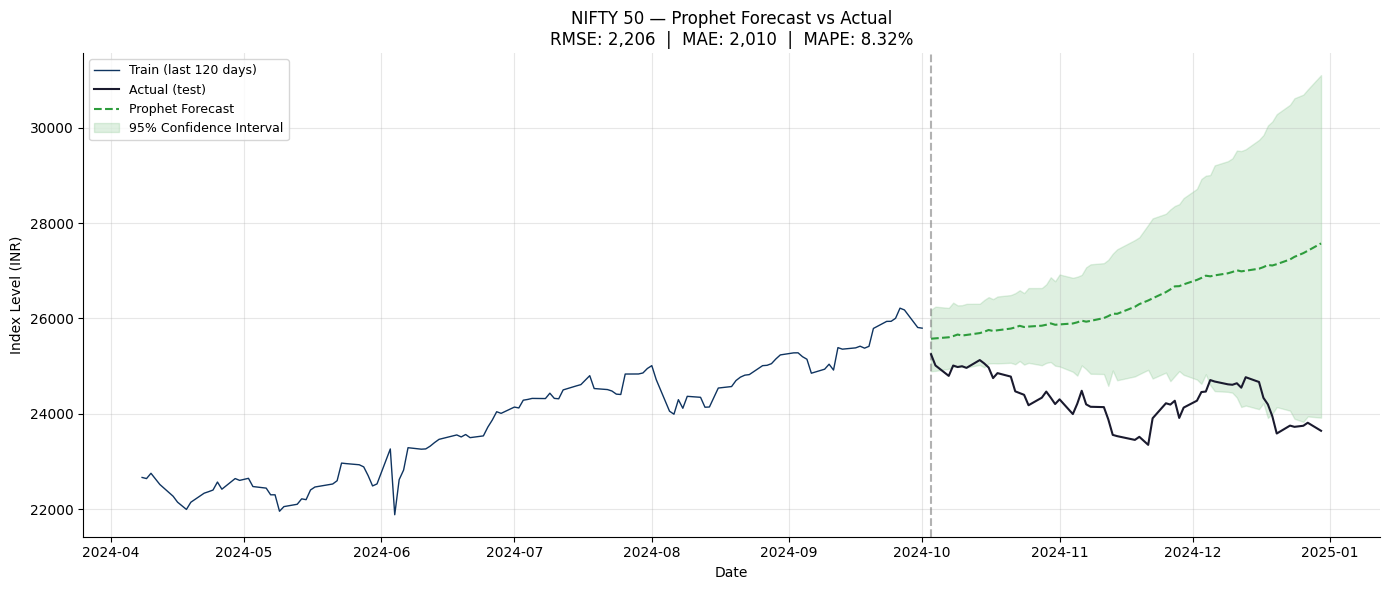

In [9]:
# Plot forecast vs actual
fig, ax = plt.subplots(figsize=(14, 6))

# Last 120 train days for context
train_tail = train_df.tail(120)
ax.plot(train_tail['ds'], train_tail['y'],
        color='#0f3460', linewidth=1, label='Train (last 120 days)')
ax.plot(test_df['ds'],   test_df['y'],
        color='#1a1a2e', linewidth=1.5, label='Actual (test)', zorder=5)
ax.plot(forecast['ds'],  forecast['yhat'],
        color='#2d9c3c', linewidth=1.5, linestyle='--', label='Prophet Forecast')
ax.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                alpha=0.15, color='#2d9c3c', label='95% Confidence Interval')
ax.axvline(test_df['ds'].iloc[0], color='gray', linestyle='--', alpha=0.6)

ax.set_title(f'NIFTY 50 — Prophet Forecast vs Actual\nRMSE: {rmse:,.0f}  |  MAE: {mae:,.0f}  |  MAPE: {mape:.2f}%',
             fontsize=12)
ax.set_ylabel('Index Level (INR)')
ax.set_xlabel('Date')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('nifty_prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Prophet Components Plot
This is Prophet's biggest advantage — you can see exactly what drives each forecast.

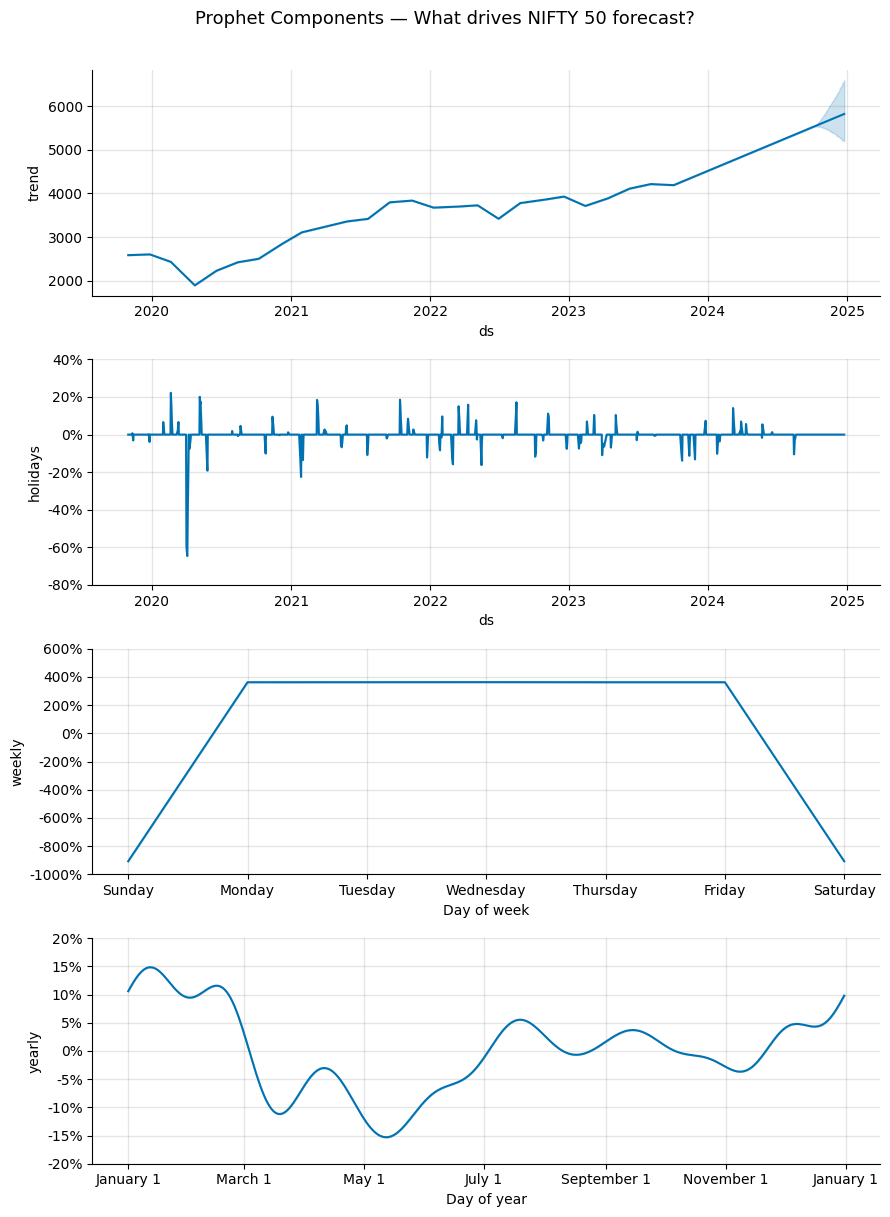

Reading the components plot:
  Trend    → long-term direction of NIFTY
  Weekly   → which days of week are stronger/weaker
  Yearly   → which months historically perform better
  Holidays → impact of budget day, Diwali etc on NIFTY


In [10]:
# Build full forecast on all data to see components clearly
future_full = model.make_future_dataframe(periods=60, freq='B')  # B = business days
forecast_full = model.predict(future_full)

fig = model.plot_components(forecast_full)
fig.suptitle('Prophet Components — What drives NIFTY 50 forecast?', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('nifty_prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()

print('Reading the components plot:')
print('  Trend    → long-term direction of NIFTY')
print('  Weekly   → which days of week are stronger/weaker')
print('  Yearly   → which months historically perform better')
print('  Holidays → impact of budget day, Diwali etc on NIFTY')

## 8. Hyperparameter Tuning
Try different `changepoint_prior_scale` values to find the best fit.

In [11]:
print('Tuning changepoint_prior_scale...')
results = []

for cps in [0.001, 0.01, 0.05, 0.1, 0.5]:
    m = Prophet(
        changepoint_prior_scale=cps,
        yearly_seasonality=True,
        weekly_seasonality=True,
        seasonality_mode='multiplicative',
        holidays=indian_holidays,
        interval_width=0.95,
    )
    m.fit(train_df)
    fc = m.predict(future)
    mape_val = np.mean(np.abs((y_true - fc['yhat'].values) / y_true)) * 100
    rmse_val = np.sqrt(mean_squared_error(y_true, fc['yhat'].values))
    results.append({'changepoint_prior_scale': cps, 'MAPE': mape_val, 'RMSE': rmse_val})
    print(f'  cps={cps:<6} → MAPE: {mape_val:.2f}%   RMSE: {rmse_val:,.0f}')

results_df = pd.DataFrame(results)
best = results_df.loc[results_df['MAPE'].idxmin()]
print(f'\nBest changepoint_prior_scale: {best["changepoint_prior_scale"]} (MAPE: {best["MAPE"]:.2f}%)')

Tuning changepoint_prior_scale...


14:27:19 - cmdstanpy - INFO - Chain [1] start processing
14:27:19 - cmdstanpy - INFO - Chain [1] done processing


  cps=0.001  → MAPE: 3.34%   RMSE: 1,055


14:27:20 - cmdstanpy - INFO - Chain [1] start processing
14:27:21 - cmdstanpy - INFO - Chain [1] done processing


  cps=0.01   → MAPE: 8.61%   RMSE: 2,273


...

  cps=0.05   → MAPE: 8.32%   RMSE: 2,206


14:27:26 - cmdstanpy - INFO - Chain [1] start processing
14:27:30 - cmdstanpy - INFO - Chain [1] done processing


  cps=0.1    → MAPE: 8.72%   RMSE: 2,283


14:27:31 - cmdstanpy - INFO - Chain [1] start processing
14:27:33 - cmdstanpy - INFO - Chain [1] done processing


  cps=0.5    → MAPE: 8.95%   RMSE: 2,325

Best changepoint_prior_scale: 0.001 (MAPE: 3.34%)


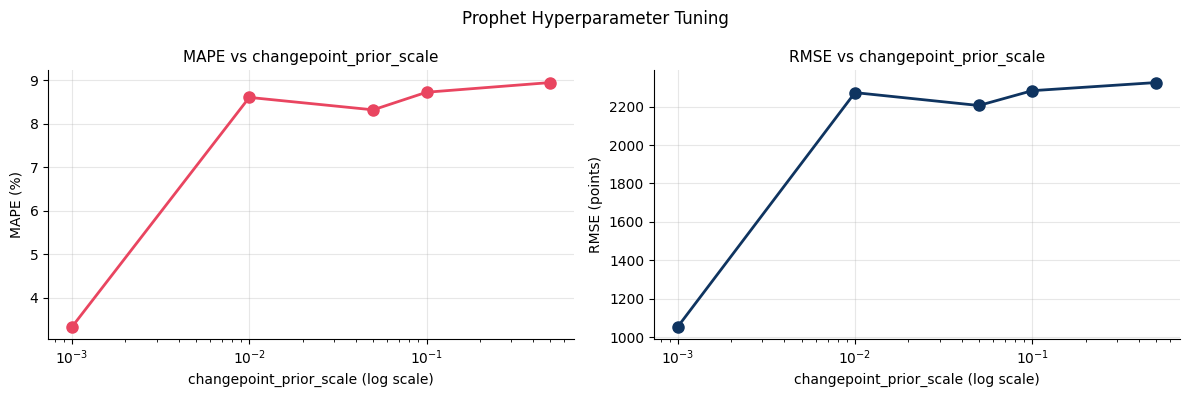

In [12]:
# Plot tuning results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(results_df['changepoint_prior_scale'], results_df['MAPE'],
             'o-', color='#e94560', linewidth=2, markersize=8)
axes[0].set_xscale('log')
axes[0].set_title('MAPE vs changepoint_prior_scale', fontsize=11)
axes[0].set_xlabel('changepoint_prior_scale (log scale)')
axes[0].set_ylabel('MAPE (%)')

axes[1].plot(results_df['changepoint_prior_scale'], results_df['RMSE'],
             'o-', color='#0f3460', linewidth=2, markersize=8)
axes[1].set_xscale('log')
axes[1].set_title('RMSE vs changepoint_prior_scale', fontsize=11)
axes[1].set_xlabel('changepoint_prior_scale (log scale)')
axes[1].set_ylabel('RMSE (points)')

plt.suptitle('Prophet Hyperparameter Tuning', fontsize=12)
plt.tight_layout()
plt.savefig('nifty_prophet_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Final tuned model

In [13]:
best_cps = best['changepoint_prior_scale']

final_model = Prophet(
    changepoint_prior_scale=best_cps,
    yearly_seasonality=True,
    weekly_seasonality=True,
    seasonality_mode='multiplicative',
    holidays=indian_holidays,
    interval_width=0.95,
)
final_model.fit(train_df)
final_fc = final_model.predict(future)

final_pred = final_fc['yhat'].values
final_rmse = np.sqrt(mean_squared_error(y_true, final_pred))
final_mae  = mean_absolute_error(y_true, final_pred)
final_mape = np.mean(np.abs((y_true - final_pred) / y_true)) * 100

print(f'Tuned Prophet (cps={best_cps}) Performance:')
print(f'  RMSE : {final_rmse:,.2f}')
print(f'  MAE  : {final_mae:,.2f}')
print(f'  MAPE : {final_mape:.2f}%')

14:27:34 - cmdstanpy - INFO - Chain [1] start processing
14:27:35 - cmdstanpy - INFO - Chain [1] done processing


Tuned Prophet (cps=0.001) Performance:
  RMSE : 1,054.75
  MAE  : 820.28
  MAPE : 3.34%


## 10. Save results

In [14]:
results_out = pd.DataFrame({
    'Date'         : test_df['ds'].values,
    'Actual'       : y_true,
    'Prophet_Pred' : final_pred,
    'Prophet_Lower': final_fc['yhat_lower'].values,
    'Prophet_Upper': final_fc['yhat_upper'].values,
}).set_index('Date')

results_out.to_csv('prophet_predictions.csv')

print('Saved: prophet_predictions.csv')
print(f'\n{"="*45}')
print('  Scoreboard so far')
print(f'{"="*45}')
print(f'  ARIMA(1,1,0)  MAPE: 0.66%')
print(f'  Prophet       MAPE: {final_mape:.2f}%')
print(f'  LSTM          MAPE: ??? (Step 4)')
print(f'{"="*45}')
print(f'\nStep 3 complete! Ready for Step 4 — LSTM')

Saved: prophet_predictions.csv

  Scoreboard so far
  ARIMA(1,1,0)  MAPE: 0.66%
  Prophet       MAPE: 3.34%
  LSTM          MAPE: ??? (Step 4)

Step 3 complete! Ready for Step 4 — LSTM


---
## Project progress

| Step | Notebook | Status |
|------|----------|--------|
| Step 1 | Data + Indicators | ✅ Done |
| Step 2 | ARIMA(1,1,0) — MAPE 0.66% | ✅ Done |
| Step 3 | Facebook Prophet | ✅ Done |
| Step 4 | LSTM | ⬅ Next |
| Step 5 | Model comparison + Backtest | Pending |